In [44]:
# Libraries we are going to need.
import os
import requests
from time import sleep
from dotenv import load_dotenv
# pip install requests newspaper3k beautifulsoup4 AND

from newspaper import Article
from datetime import date, timedelta
from bs4 import BeautifulSoup
from collections import defaultdict
import csv
import pandas as pd
import gensim.models
from gensim.models import Word2Vec


import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA



In [45]:
# List of query words
COUNTRIES = [
    # Major powers / G20
    "united_states", "china", "russia", "india", "germany", "france",
    "united_kingdom", "japan", "italy", "canada", "brazil", "australia",
    "south_korea", "saudi_arabia", "mexico", "indonesia", "turkey",
    "argentina", "south_africa",

    # Europe (expanded)
    "ukraine", "poland", "netherlands", "belgium", "sweden", "norway",
    "denmark", "finland", "switzerland", "austria", "spain", "portugal",
    "greece", "hungary", "czech_republic", "romania", "bulgaria",
    "serbia", "ireland",

    # Middle East
    "israel", "iran", "iraq", "syria", "lebanon", "jordan",
    "united_arab_emirates", "qatar", "kuwait", "oman", "yemen",

    # Africa
    "nigeria", "ethiopia", "egypt", "kenya", "south_africa",
    "ghana", "morocco", "algeria", "tunisia", "sudan",
    "democratic_republic_of_congo", "uganda", "tanzania",

    # Asia
    "pakistan", "bangladesh", "vietnam", "thailand", "philippines",
    "malaysia", "singapore", "taiwan", "north_korea",

    # Americas
    "chile", "peru", "colombia", "venezuela", "cuba",
    "bolivia", "ecuador", "paraguay", "uruguay",

    # Special / geopolitical
    "palestine", "kosovo", "hong_kong"
]

LEADERS = [
    # Major powers
    "joe_biden", "donald_trump", "xi_jinping", "vladimir_putin",
    "narendra_modi", "emmanuel_macron", "olaf_scholz",
    "keir_starmer", "rishi_sunak", "justin_trudeau",

    # Europe
    "volodymyr_zelenskyy", "ursula_von_der_leyen",
    "giorgia_meloni", "mark_rutte",

    # Middle East
    "benjamin_netanyahu", "ali_khamenei", "mohammed_bin_salman",
    "bashar_al_assad",

    # Asia
    "kim_jong_un", "lai_ching_te",

    # Americas
    "lula_da_silva", "javier_milei", "andres_manuel_lopez_obrador",

    # Africa
    "bola_tinubu", "abiy_ahmed",

    # International org leaders
    "antonio_guterres", "klaus_schwab"
]

EVENTS = [
    # Wars / conflicts
    "ukraine_war", "russia_ukraine_war", "gaza_war",
    "israel_hamas_war", "syrian_civil_war",

    # Political processes
    "brexit", "election", "midterm_election", "general_election",
    "referendum",

    # Global crises
    "covid_19", "pandemic", "inflation", "recession",
    "energy_crisis", "climate_change",

    # Policy / governance
    "sanctions", "trade_war", "immigration", "border_policy",
    "foreign_policy", "defense_policy",

    # Tech / geopolitics
    "artificial_intelligence", "ai_regulation",
    "cybersecurity", "surveillance",

    # Economy
    "global_economy", "interest_rates", "central_bank",
    "supply_chain", "oil_prices"
]

INSTITUTIONS = [
    "nato", "united_nations", "eu", "european_union",
    "world_bank", "imf", "world_health_organization",
    "wto", "g7", "g20", "brics",
    "white_house", "kremlin", "downing_street",
    "pentagon", "european_commission"
]

QUERY_TERMS = COUNTRIES + LEADERS + EVENTS + INSTITUTIONS

In [46]:
df = pd.read_csv('guardian_2023.csv')

guardian_sentences = [doc.split() for doc in df['Title']]
model = Word2Vec(sentences=guardian_sentences, vector_size=100, window=5, min_count=5, workers=4, sg=1)

vector = model.wv['day']



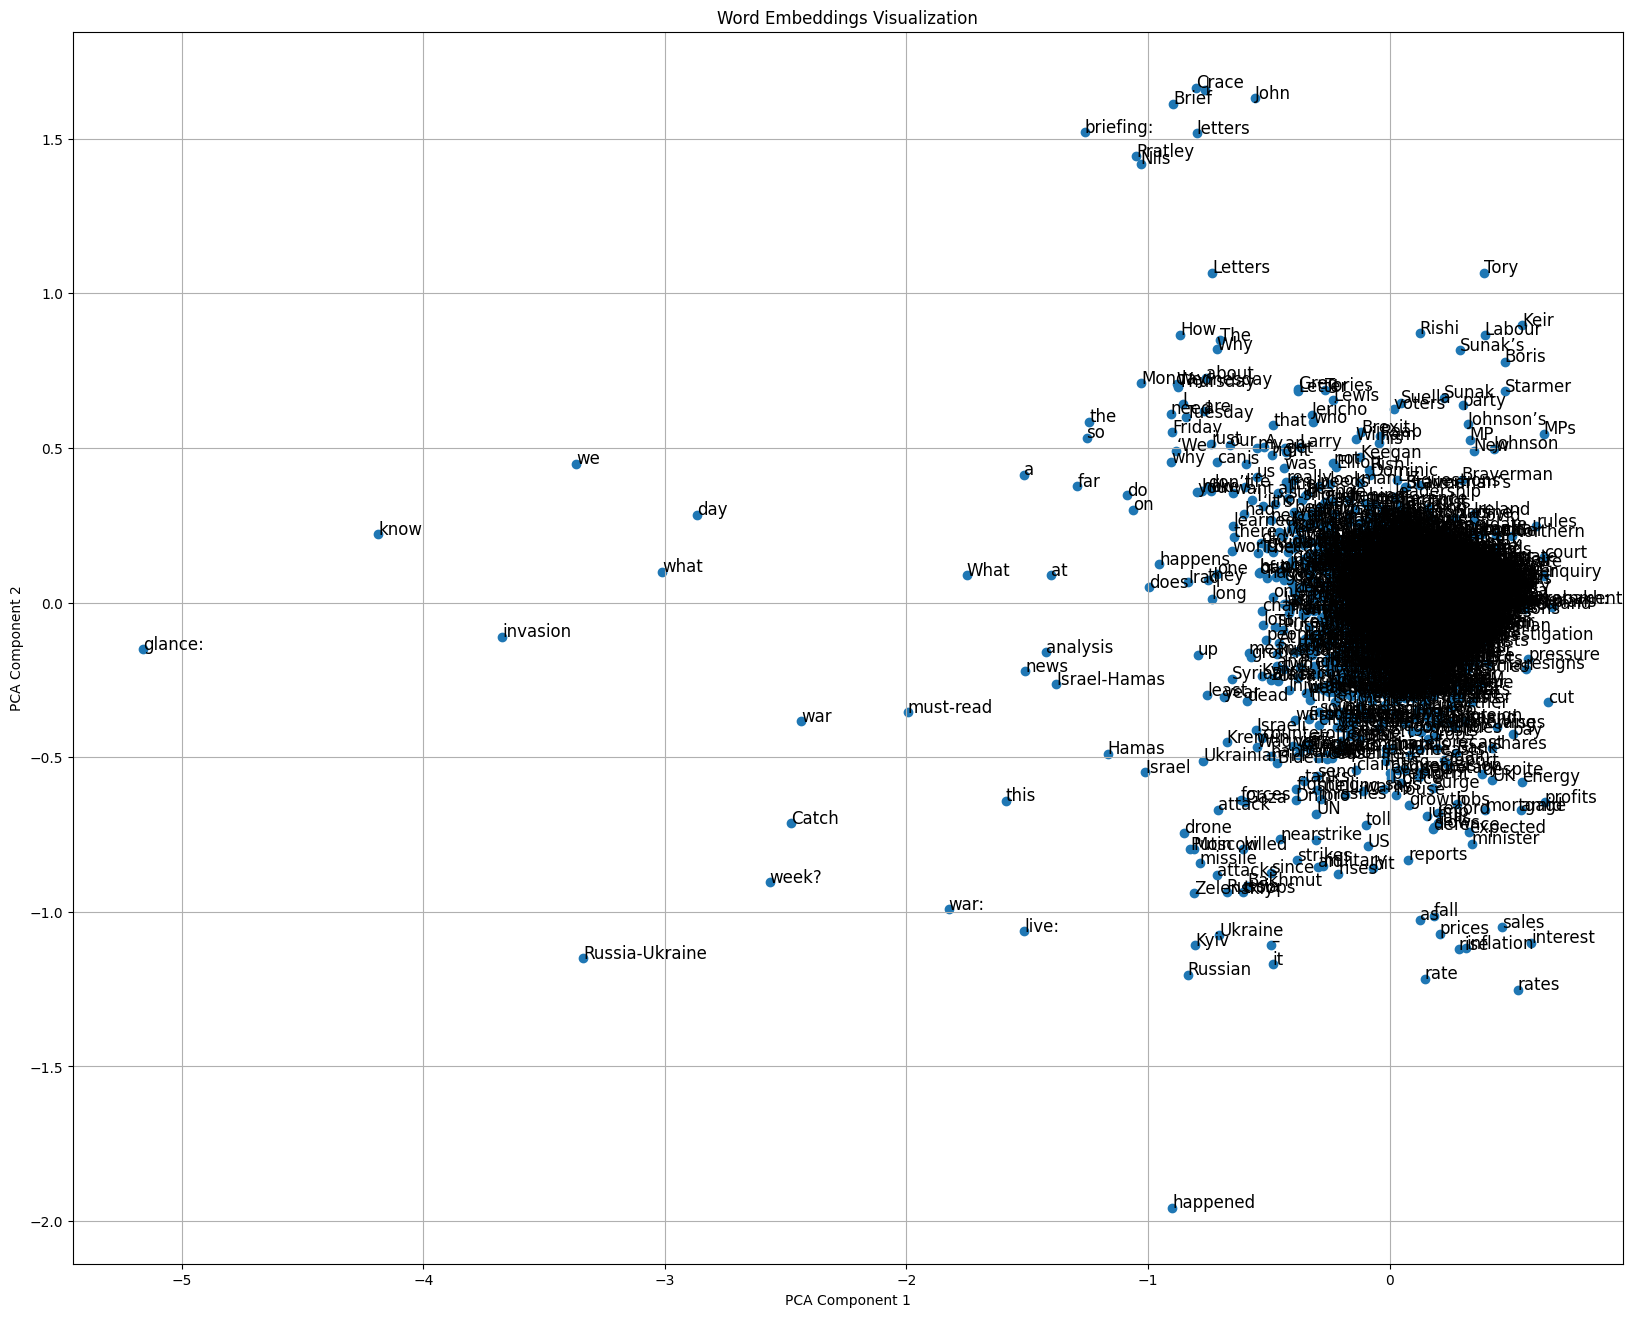

In [47]:
#visualize with a graph

# Reduce dimensionality of word vectors for visualization
word_vectors = model.wv[model.wv.index_to_key]  # Get the word vectors
pca = PCA(n_components=2)  # Initialize PCA
result = pca.fit_transform(word_vectors)  # Fit and transform the word vectors

# Plot the words in a 2D space
plt.figure(figsize=(20, 16))
plt.scatter(result[:, 0], result[:, 1])

# Annotate words in the plot
words = list(model.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()